In [42]:
import glob

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import sunpy
import sunpy.map
from astropy.coordinates import SkyCoord
from astropy.coordinates import SpectralCoord
import astropy.units as u
from astropy.io import fits

from irispy.io import read_files

from sunpy.physics.differential_rotation import differential_rotate
from scipy.ndimage import gaussian_filter1d, median_filter, zoom
from sunpy.coordinates import get_earth

import cmasher as cmr

import sys
sys.path.insert(0, '..')
from scripts.helpers import find_closest_hmi,find_closest_aia
from scripts.ribbon_map import RibbonMap as RM
from scripts.ribbon_map import RibbonCoords as RC
from scripts.ribbon_map import iris_reproject

import scienceplots
from sunpy.visualization.colormaps import color_tables as ct
plt.rcParams.update({'font.size': 14})
plt.style.use(['bright'])
# plt.rcParams['font.family'] = 'Atkinson Hyperlegible Next'
sdoaia1600 = ct.aia_color_table(1600*u.angstrom)
sji1400cm = ct.iris_sji_color_table('1400')
sji1400cm.set_bad('black')





In [43]:
time = '2026-02-03 14:15:26'
fn = '/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/hmi.m_45s.20260203_141545_TAI.2.magnetogram.fits'

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

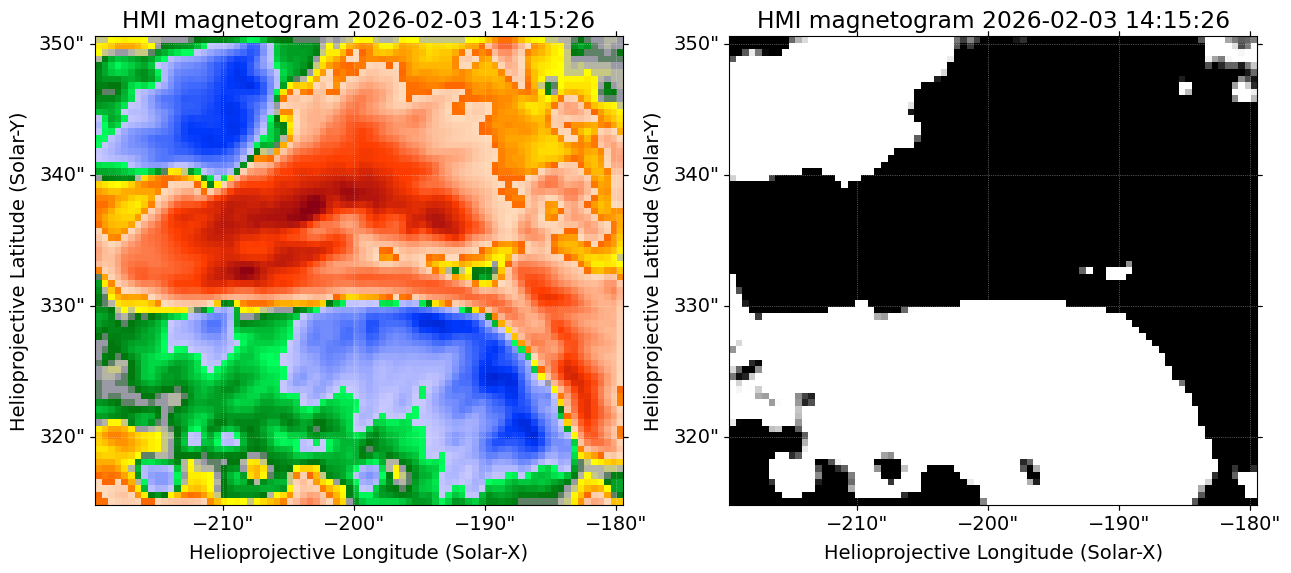

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


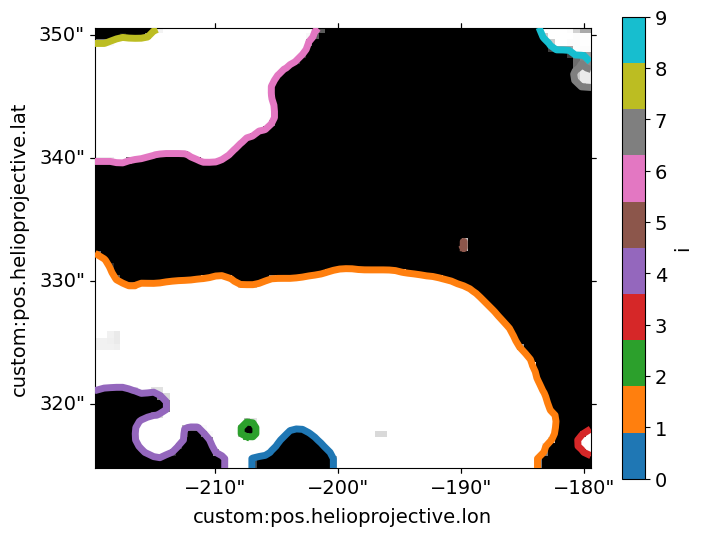

In [44]:
hmap = sunpy.map.Map(fn)
hmap = hmap.rotate(order=3)

xl, xr, yb, yt = -220, -180, 315, 350

xlims_world = [xl, xr]*u.arcsec 
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=hmap.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=hmap.coordinate_frame)

hmap = hmap.submap(lb, top_right=tr)
hmap = differential_rotate(hmap, time=time)


# --------------- Plot ---------------
fig = plt.figure(figsize=(15,8))

ax = fig.add_subplot(121, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-1500.0, vmax=1500.0)

ax = fig.add_subplot(122, projection=hmap)
hmap.plot(axes=ax, cmap=cmr.neutral, norm=None, vmin=-10.0, vmax=10.0)

smoothed = median_filter(hmap.data, size=4) 
smooth_map = sunpy.map.Map(smoothed, hmap.meta)

hmi_PIL = smooth_map.find_contours(0 * u.G)
ihmax = np.argmax([h.shape[0] for h in hmi_PIL])

pil = hmi_PIL[9]

norm=mcolors.Normalize(vmin=0.0, vmax=len(hmi_PIL)-1)
cmap =cm.tab10

fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': smooth_map})
im = ax.imshow(smoothed, origin='lower', cmap="Greys_r", vmin=-10.0, vmax=10.0)

for i in range(len(hmi_PIL)):
    ax.plot_coord(hmi_PIL[i], color=cmap(norm(i)), linewidth=5)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("i")

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

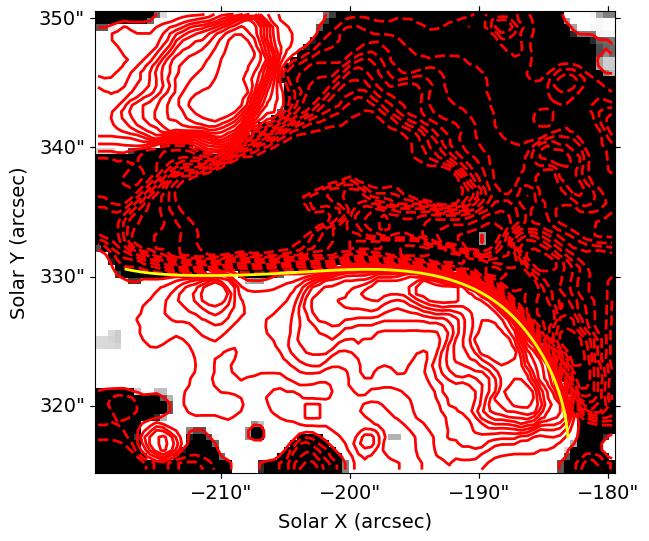

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

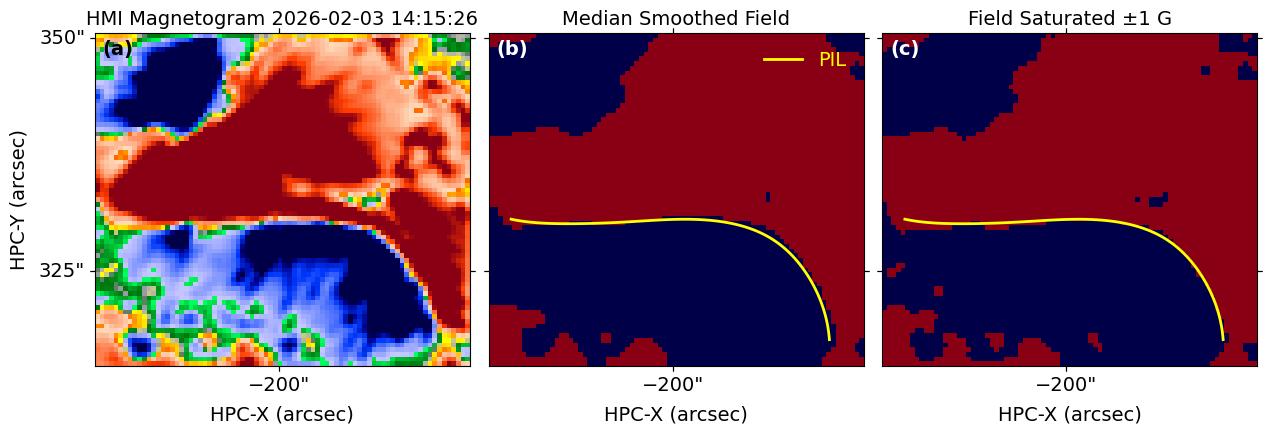

In [45]:
smoothed = median_filter(hmap.data, size=4) 
smooth_map = sunpy.map.Map(smoothed, hmap.meta)

hmi_PIL = smooth_map.find_contours(0 * u.G)
ihmax = np.argmax([h.shape[0] for h in hmi_PIL])

# pil = hmi_PIL[ihmax]
pil = hmi_PIL[1]
# use pil = hmi_PIL[ihmax] or pil = hmi_PIL[#] dependant on which PIL you want to use. The index can be changed to select different PILs.

tx_smooth = gaussian_filter1d(pil.Tx.arcsec, sigma=10)
ty_smooth = gaussian_filter1d(pil.Ty.arcsec, sigma=10)

hmi_PIL_smooth = SkyCoord(tx_smooth * u.arcsec, ty_smooth * u.arcsec,
                          frame=smooth_map.coordinate_frame)

hmi_arcsec = np.column_stack([hmi_PIL_smooth.Tx.arcsec, hmi_PIL_smooth.Ty.arcsec])
np.savetxt('auxiliary_data/hmi_pil_world_median.csv', hmi_arcsec, delimiter=',', header='Tx_arcsec,Ty_arcsec')


# --------------- Plot ---------------
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': smooth_map})
im = ax.imshow(smoothed, origin='lower', cmap=cmr.neutral, vmin=-10.0, vmax=10.0)

plt.contour(smoothed, levels=np.linspace(-1000, 1000, 21), colors='red', linewidths=2)
ax.plot_coord(hmi_PIL_smooth,color='yellow', linewidth=2)

ax.set_ylabel('Solar Y (arcsec)')
ax.set_xlabel('Solar X (arcsec)')

fig = plt.figure(figsize=(15, 8))


ax = fig.add_subplot(131, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-500.0, vmax=500.0)
ax.set_xlabel('HPC-X (arcsec)')
ax.set_ylabel('HPC-Y (arcsec)')
ax.set_title(f'HMI Magnetogram {hmap.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=14)
ax.grid(False)
ax.coords[0].set_ticks(spacing=25 * u.arcsec)   
ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='black', fontweight='bold')

ax = fig.add_subplot(132, projection=smooth_map)
im = ax.imshow(smoothed, origin='lower', cmap="hmimag", vmin=-.001, vmax=0.001)
ax.coords[1].set_ticklabel_visible(False)
ax.coords[1].set_axislabel('')
ax.set_xlabel('HPC-X (arcsec)')
ax.set_title('Median Smoothed Field', fontsize=14)
ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2, label='PIL')
ax.legend(loc='upper right', frameon=False, labelcolor='yellow')
ax.coords[0].set_ticks(spacing=25 * u.arcsec)  
ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

ax = fig.add_subplot(133, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-.001, vmax=0.001)
ax.coords[1].set_ticklabel_visible(False)
ax.coords[1].set_axislabel('')
ax.set_xlabel('HPC-X (arcsec)')
ax.set_title('Field Saturated ±1 G', fontsize=14)
ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2)
ax.grid(False)
ax.coords[0].set_ticks(spacing=25 * u.arcsec)   
ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
ax.text(0.02, 0.98, '(c)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

plt.subplots_adjust(wspace=0.05)
# plt.savefig('figures/hmi_pil_smoothing.pdf', dpi=300, bbox_inches='tight')


/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

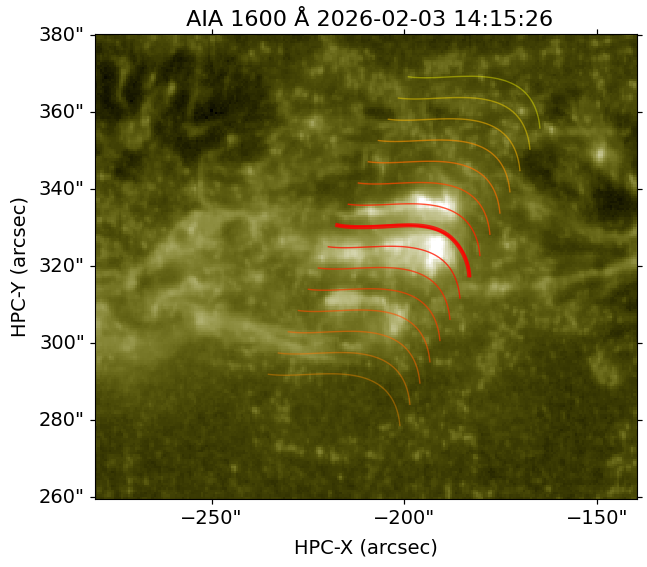

In [46]:
ref_map =  sunpy.map.Map('/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/aia.lev1.1600A_2026_02_03T14_15_26.12Z.image_lev1.fits')

xl, xr, yb, yt = -140, -280, 260, 380 # larger FOV to capture more of the ribbons

xlims_world = [xl, xr]*u.arcsec #small
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=ref_map.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=ref_map.coordinate_frame)

amap = ref_map.submap(lb, top_right=tr)

pil_world = SkyCoord(hmi_arcsec[:,0]*u.arcsec, hmi_arcsec[:,1]*u.arcsec, 
                     frame=ref_map.coordinate_frame)
separations = pil_world[1:].separation(pil_world[:-1]).to(u.arcsec)

arcsec = np.concatenate([[0], np.cumsum(separations.value)]) * u.arcsec
intensity = sunpy.map.sample_at_coords(amap, pil_world)

rmap,xarc,yarc = RM(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=ref_map)
slice_coords, cross_arcsec = RC(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=ref_map)

fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(projection=amap)
amap.plot(axes=ax,vmax=np.percentile(amap.data, 99.9))
ax.grid(False)
ax.set_title(f' AIA 1600 Å {amap.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=16)
ax.set_xlabel('HPC-X (arcsec)')
ax.set_ylabel('HPC-Y (arcsec)')

ax.plot_coord(pil_world, linewidth=3, color='red',alpha=0.8)

center_idx = np.argmin(np.abs(cross_arcsec))  # index where offset ≈ 0
start = center_idx % 10                        # shift so center_idx lands in the sample
slices = slice_coords[start::10]
mid = (center_idx - start) // 10              # index of offset=0 within `slices`

for i, sc in enumerate(slices):
    t = abs(i - mid) / max(mid, len(slices) - 1 - mid)
    lw = 1.4 - 0.8 * t
    alpha = 0.85 - 0.45 * t
    if i <= mid:
        frac = (mid - i) / max(mid, 1)
        color = (1.0, 0.55 * frac, 0.0)
    else:
        frac = (i - mid) / max(len(slices) - 1 - mid, 1)
        color = (1.0, frac, 0.0)
    ax.plot_coord(sc, linewidth=1.0, color=color, alpha=alpha)

# fig.savefig('figures/aia_pil_ribbons.pdf', dpi=300, bbox_inches='tight') 

(179, 82) -> (148, 68) (target: (148, 68) )


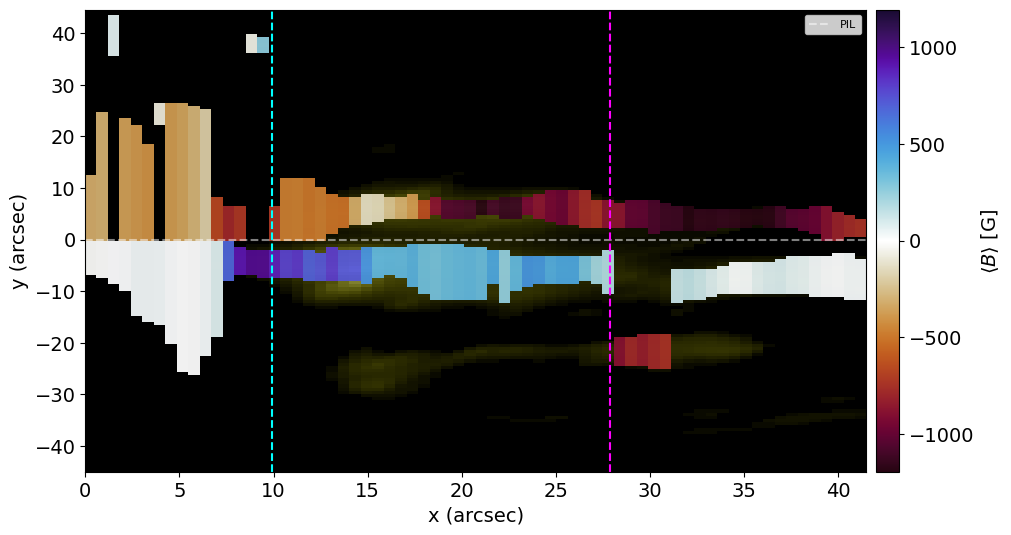

In [47]:
hmap = sunpy.map.Map(fn)
hmap = hmap.rotate(order=3)

xlims_world = [xl, xr]*u.arcsec 
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=hmap.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=hmap.coordinate_frame)

hmap = hmap.submap(lb, top_right=tr)

hmi_warped,h_xarc,h_yarc = RM(hmap, pil_world, xoffsets=[-45, 45], diff_rotate=False)

zoom_factors = (rmap.shape[0] / hmi_warped.shape[0], rmap.shape[1] / hmi_warped.shape[1])
hmi_warped_interp = zoom(hmi_warped, zoom_factors, order=3)

print(hmi_warped.shape, '->', hmi_warped_interp.shape, '(target:', rmap.shape, ')')

zero_idx = np.argmin(np.abs(yarc))

def fwhm_bounds(prof, offset=0):
    peak_i = np.argmax(prof)
    half = prof[peak_i] *0.5
    lo = peak_i
    while lo > 0 and prof[lo] > half:
        lo -= 1
    hi = peak_i
    while hi < len(prof) - 1 and prof[hi] > half:
        hi += 1
    return lo + offset, hi + offset

n_cols = rmap.shape[1]
a_arr, b_arr, c_arr, d_arr, mean_hmi_ab, mean_hmi_cd = [np.full(n_cols, np.nan) for _ in range(6)]

for idx in range(n_cols):
    profile = rmap[:, idx]

    d, c = fwhm_bounds(profile[:zero_idx])
    b, a = fwhm_bounds(profile[zero_idx:], zero_idx)

    a_arr[idx] = a
    b_arr[idx] = b
    c_arr[idx] = c
    d_arr[idx] = d
    mean_hmi_ab[idx] = np.median(hmi_warped_interp[b:a+1, idx])  # upper ribbon
    mean_hmi_cd[idx] = np.median(hmi_warped_interp[d:c+1, idx])  # lower ribbon


fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(rmap, aspect='auto', origin='lower',
          extent=[0, xarc[-1], yarc[0], yarc[-1]],
          cmap=sdoaia1600, vmin=300, vmax=10000, interpolation='None')


vlim = np.nanpercentile(np.abs(np.concatenate([mean_hmi_ab, mean_hmi_cd])), 99)
norm = Normalize(vmin=-vlim, vmax=vlim)
cmap_b = cmr.fusion

overlay = np.zeros((*rmap.shape, 4))
for idx in range(rmap.shape[1]):
    if np.isnan(a_arr[idx]):
        continue
    a, b, c, d = int(a_arr[idx]), int(b_arr[idx]), int(c_arr[idx]), int(d_arr[idx])
    overlay[b:a+1, idx] = (*cmap_b(norm(mean_hmi_ab[idx]))[:3], 0.95)
    overlay[d:c+1, idx] = (*cmap_b(norm(mean_hmi_cd[idx]))[:3], 0.95)

ax.imshow(overlay, aspect='auto', origin='lower',
          extent=[0, xarc[-1], yarc[0], yarc[-1]], interpolation='None')

ax.axhline(0, color='white', linestyle='--', alpha=0.5, label='PIL')
ax.set_xlabel('x (arcsec)')
ax.set_ylabel('y (arcsec)')


# --------------- Plot ---------------
plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_b),
             ax=ax, label=r'$\langle B \rangle$ [G]', pad=0.01)
ax.legend(fontsize=8)

# show extent ribbon locations, cropped region
xl,xr = 16, 45

ax.axvline(xarc[xl], color='cyan', linestyle='--', label='xl')
ax.axvline(xarc[xr], color='magenta', linestyle='--', label='xr')

rmap_crop = rmap[:, xl:xr]
xarc_crop = xarc[xl:xr]
xarc_crop = xarc[::-1][xl:xr]


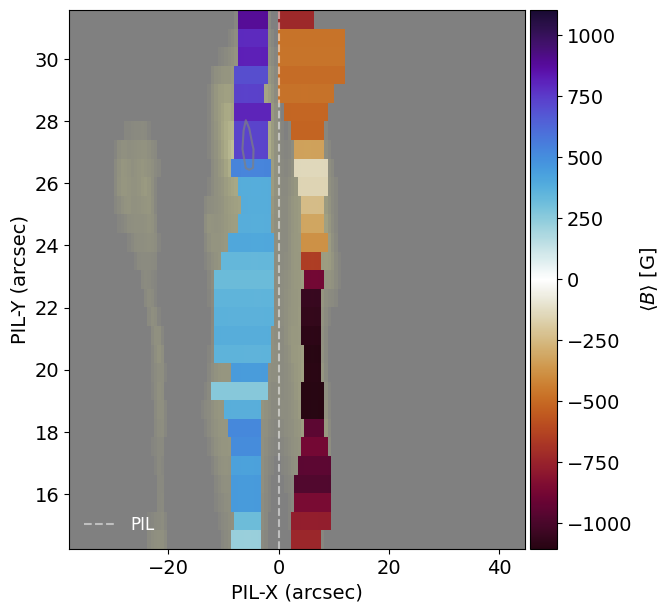

In [48]:
fig, ax = plt.subplots(figsize=(7, 7))  

ax.imshow(rmap_crop.T, aspect='auto', origin='lower',
          extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],  # swapped
          cmap=sdoaia1600, vmin=400, vmax=10000, interpolation='None', alpha=0.5)

vlim = np.nanpercentile(np.abs(np.concatenate([mean_hmi_ab[xl:xr], mean_hmi_cd[xl:xr]])), 95)
norm = Normalize(vmin=-vlim, vmax=vlim)
cmap_b = cmr.fusion

overlay = np.zeros((*rmap_crop.T.shape, 4))  
for i, idx in enumerate(range(xl, xr)):
    if np.isnan(a_arr[idx]):
        continue
    a, b, c, d = int(a_arr[idx]), int(b_arr[idx]), int(c_arr[idx]), int(d_arr[idx])
    overlay[i, b:a+1] = (*cmap_b(norm(mean_hmi_ab[idx]))[:3], 0.99)  
    overlay[i, d:c+1] = (*cmap_b(norm(mean_hmi_cd[idx]))[:3], 0.99)

ax.imshow(overlay, aspect='auto', origin='lower',
          extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],  
          interpolation='None')

ax.set_ylabel('PIL-Y (arcsec)')
ax.set_xlabel('PIL-X (arcsec)')

ax.axvline(0, color='white', linestyle='--', label='PIL',alpha=0.5)

plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_b),
             ax=ax, label=r'$\langle B \rangle$ [G]', pad=0.01)
ax.legend(fontsize=12, frameon=False, labelcolor='white', loc='lower left')

contours = ax.contour(rmap_crop.T, levels=[7500],
                      extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],
                      colors='grey', linewidths=1.5, alpha=0.7,
                      origin='lower')

ax.set_xlim(-38) 
ax.invert_yaxis()

# fig.savefig(f'figures/aia1600_ribbon_map_zoom_{amap.date.iso}.pdf', dpi=300, bbox_inches='tight')

Si IV Raster prep

In [49]:
fits_dir = '/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/SJI/'
raster_files = sorted(glob.glob(fits_dir + '*.fits'))

raster = read_files(raster_files, memmap=False)

In [50]:
siiv = raster['Si IV 1403']
siiv[118].time
siiv.shape

(432, 8, 204, 247)

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


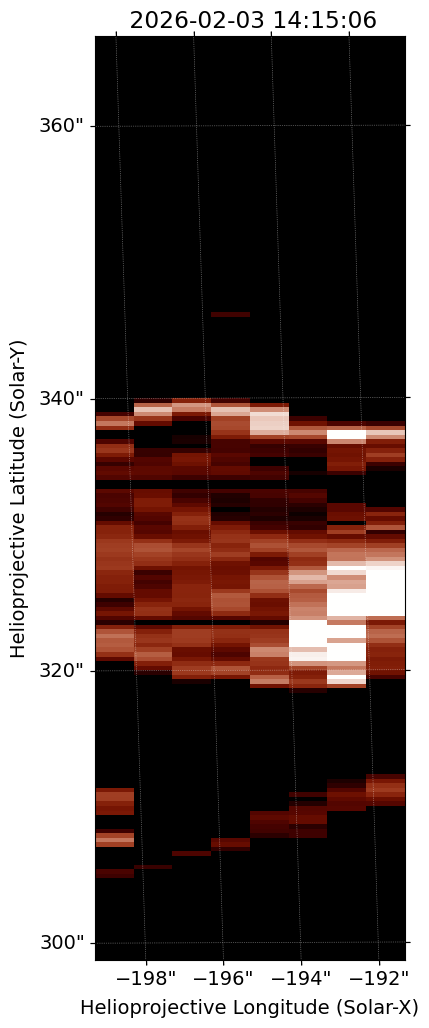

In [51]:
it = 118

# we are only instersted in the Si IV 1403 line, so crop to that wavelength range (roughly here)
wvl_min = [SpectralCoord(1402.5, unit=u.Angstrom), None]
wvl_max = [SpectralCoord(1404.25, unit=u.Angstrom), None]

siiv_spec   = siiv[it].crop(wvl_min, wvl_max)
siiv_raster = siiv_spec.data.sum(axis=2)    


cel = siiv_spec.wcs.low_level_wcs._wcs.celestial.swapaxes(0, 1)
hdr = cel.to_header()


oh = siiv_spec.meta.original_meta
hdr['DATE-OBS'] = oh['DATE_OBS']
hdr['DSUN_OBS'] = oh['DSUN_OBS']
hdr['telescop'] = 'IRIS'
hdr['instrume'] = 'SPEC'

siiv_map = sunpy.map.Map(siiv_raster.T, hdr)      # .T to match the swapped WCS / your figure

#siiv_map.peek(norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm)

fig = plt.figure(figsize=(4,12))
ax = fig.add_subplot(projection=siiv_map)
siiv_map.plot(axes=ax, norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm, aspect='auto')


IRIS SJI Map

In [52]:
ny, nx = rmap_crop.shape

data = np.column_stack([
    a_arr[xl:xr] / ny,
    b_arr[xl:xr] / ny,
    c_arr[xl:xr] / ny,
    d_arr[xl:xr] / ny,
    mean_hmi_ab[xl:xr],
    mean_hmi_cd[xl:xr],
])

np.savetxt(
    'auxiliary_data/ribbon_bounds.txt',
    data,
    header='a  b  c  d  mean_hmi_ab  mean_hmi_cd',
    fmt='%.6f',
)
print(f"Saved {data.shape[0]} rows to ribbon_bounds.txt")

np.save('auxiliary_data/rmap_crop.npy', rmap_crop)
print(f"Saved rmap_crop {rmap_crop.shape} to auxiliary_data/rmap_crop.npy")

Saved 29 rows to ribbon_bounds.txt
Saved rmap_crop (148, 29) to auxiliary_data/rmap_crop.npy


/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


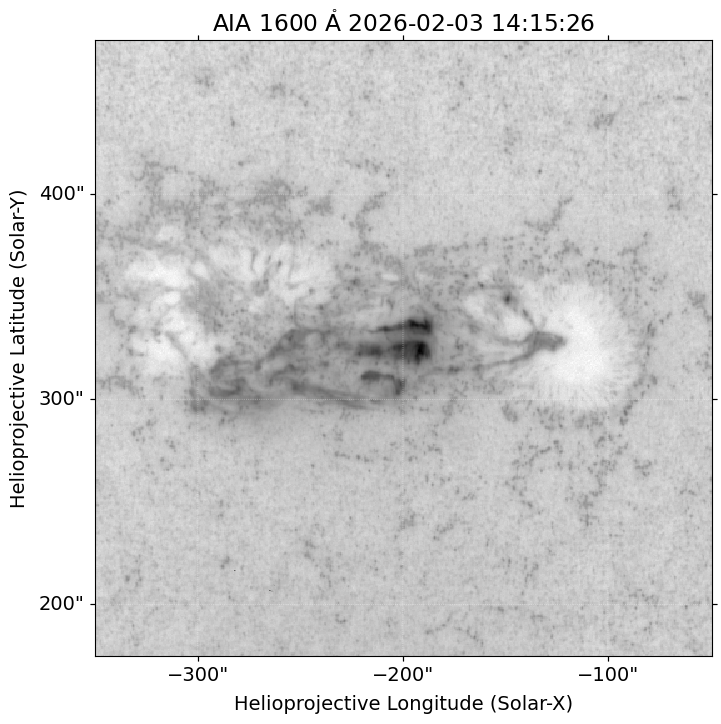

In [53]:
aia_fn = '/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/aia.lev1.1600A_2026_02_03T14_15_26.12Z.image_lev1.fits'

ref_map = sunpy.map.Map(aia_fn)

XL, XR, YB, YT = -350, -50, 175, 475 # larger FOV to capture more of the ribbons


xlims_world = [XL, XR]*u.arcsec #small
ylims_world = [YB, YT]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=ref_map.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=ref_map.coordinate_frame)

amap = ref_map.submap(lb, top_right=tr)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=amap)
amap.plot(axes=ax,norm=LogNorm(),cmap=cmr.neutral_r)

In [54]:
def raster_reproject(raster_map, ref_aia_map):

    # WCS axis 1 = x (raster-step), axis 2 = y (along-slit)
    ratio_x = (ref_aia_map.scale[0] / raster_map.scale[0]).decompose().value
    ratio_y = (ref_aia_map.scale[1] / raster_map.scale[1]).decompose().value
    ratio = np.array([ratio_x, ratio_y])

    earth_obs = get_earth(raster_map.date)
    raster_map.meta['hgln_obs'] = earth_obs.lon.to_value('deg')
    raster_map.meta['hglt_obs'] = earth_obs.lat.to_value('deg')
    raster_map.meta['dsun_obs'] = earth_obs.radius.to_value('m')

    new_wcs = ref_aia_map.wcs.deepcopy()
    new_wcs.wcs.cdelt = new_wcs.wcs.cdelt / ratio

    # preserve pixel alignment with rescaling.
    new_wcs.wcs.crpix = (ref_aia_map.wcs.wcs.crpix - 0.5) * ratio + 0.5
    new_wcs.wcs.dateobs = raster_map.date.iso

    raster_map.meta['rsun_ref'] = ref_aia_map.meta['rsun_ref']
    raster_map = sunpy.map.Map(raster_map.data, raster_map.meta)

    shape_out = (
        int(np.round(ref_aia_map.data.shape[0] * ratio_y)),  # rows -> y
        int(np.round(ref_aia_map.data.shape[1] * ratio_x)),  # cols -> x
    )

    # print(raster_map.meta.get('hgln_obs'), raster_map.meta.get('hglt_obs'), raster_map.meta.get('dsun_obs'))
    # print(ref_aia_map.meta.get('hgln_obs'), ref_aia_map.meta.get('hglt_obs'), ref_aia_map.meta.get('dsun_obs'))

    return raster_map.reproject_to(new_wcs, shape_out=shape_out)


/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

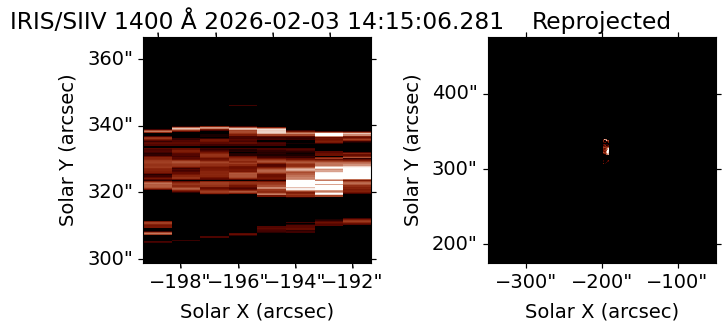

In [55]:
# --------------- Plot ---------------
fig = plt.figure(figsize=(7, 6))

ax1 = fig.add_subplot(2, 2, 1, projection=siiv_map)
siiv_map.plot(axes=ax1, norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm, aspect='auto')
ax1.coords.grid(False)
ax1.set_xlabel('Solar X (arcsec)')
ax1.set_ylabel('Solar Y (arcsec)')




date_str = siiv_map.date.value.split('T')
ax1.set_title(f'IRIS/SIIV 1400 Å {date_str[0]} {date_str[1]}')

siiv_reproj = raster_reproject(siiv_map, amap)
ax2 = fig.add_subplot(2, 2, 2, projection=siiv_reproj)
siiv_reproj.plot(axes=ax2, norm=LogNorm(vmin=200, vmax=4e3), cmap=sji1400cm, aspect='auto')
ax2.coords.grid(False)
ax2.set_xlabel('Solar X (arcsec)')
ax2.set_ylabel('Solar Y (arcsec)')
ax2.set_title('Reprojected')

plt.tight_layout()

IRIS Reproject

In [56]:
pil_world = SkyCoord(hmi_arcsec[:,0]*u.arcsec, hmi_arcsec[:,1]*u.arcsec, 
                     frame=siiv_reproj.coordinate_frame)
separations = pil_world[1:].separation(pil_world[:-1]).to(u.arcsec)

arcsec = np.concatenate([[0], np.cumsum(separations.value)]) * u.arcsec
intensity = sunpy.map.sample_at_coords(siiv_reproj, pil_world)

rmap_sji,xarc_sji,yarc_sji = RM(siiv_reproj, pil_world, xoffsets=[-45, 45], diff_rotate=False, ref_map=siiv_reproj)

xarc_sji = xarc_sji[::-1]


15 41


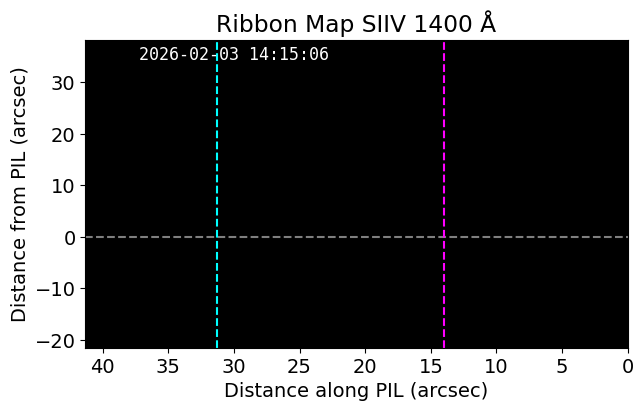

In [57]:
# Extract the exposure value if it exists, otherwise default to 1.0 (or your known exposure)
exp_time = siiv_map.exposure_time.value if siiv_map.exposure_time is not None else 1.0

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    np.isfinite(rmap_sji / exp_time),  # Safe division
    aspect='auto', 
    origin='lower', 
    extent=[xarc_sji[0], xarc_sji[-1], yarc_sji[0], yarc_sji[-1]], 
    cmap=sji1400cm, 
    norm=LogNorm(vmin=10.0, vmax=3000), 
    interpolation='None'
)

ax.axhline(0, color='white', linestyle='--', label='PIL location',alpha=0.5)

ax.set_xlabel('Distance along PIL (arcsec)')
ax.set_ylabel('Distance from PIL (arcsec)')
ax.set_title(f'Ribbon Map SIIV 1400 Å')

ax.text(0.45, 0.98, siiv_reproj.date.iso[:19], transform=ax.transAxes,
        fontsize=12, va='top', ha='right',
        fontfamily='monospace',color='white')

ax.set_ylim(-21.5)  # was set_ylim

xl,xr = np.argmin(np.abs(xarc_sji-xarc_crop[0])),np.argmin(np.abs(xarc_sji-xarc_crop[-1]))
print(xl,xr)

ax.axvline(xarc_sji[xl], color='cyan', linestyle='--', label='xl')
ax.axvline(xarc_sji[xr], color='magenta', linestyle='--', label='xr')

rmap_sji_crop = rmap_sji[:, xl:xr]
xarc_sji_crop = xarc_sji[xl:xr]


IRIS AIA Data Reprojected

In [58]:
indices = np.argmin(np.abs(xarc_sji_crop[:, None] - xarc_crop[None, :]), axis=1)

np.savez('auxiliary_data/rmap_sji_data.npz', rmap_sji_crop=rmap_sji_crop, indices=indices)
print(f"Saved rmap_sji_data with rmap_sji_crop {rmap_sji_crop.shape} and indices {indices.shape} to auxiliary_data/rmap_sji_data.npz")

Saved rmap_sji_data with rmap_sji_crop (91, 26) and indices (26,) to auxiliary_data/rmap_sji_data.npz


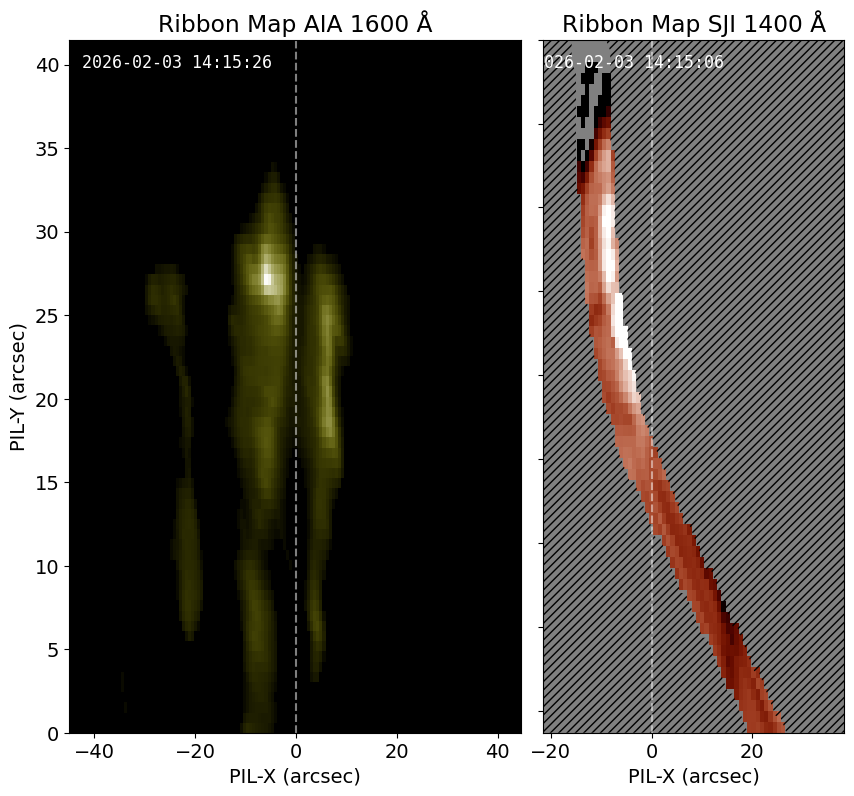

In [59]:
x1_range = float(yarc[-1] - yarc[0])
x2_lo = -21.5
x2_range = float(yarc_sji[-1] - x2_lo)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6 * (x1_range + x2_range) / x1_range, 9),
    gridspec_kw={'width_ratios': [x1_range, x2_range], 'wspace': 0.06},
)

im1 = ax1.imshow(rmap.T, aspect='auto', origin='lower',
                 extent=[yarc[0], yarc[-1], xarc[-1], 0],
                 cmap=sdoaia1600, vmin=400, vmax=10000, interpolation='None')

ax1.axvline(0, color='white', linestyle='--', label='PIL location', alpha=0.5)
ax1.set_ylabel('PIL-Y (arcsec)')
ax1.set_xlabel('PIL-X (arcsec)')
ax1.set_title('Ribbon Map AIA 1600 Å')
ax1.text(0.45, 0.98, amap.date.iso[:19], transform=ax1.transAxes,
         fontsize=12, va='top', ha='right', fontfamily='monospace', color='white')
ax1.invert_yaxis()

if siiv_map.exposure_time is not None:
    exp_time = siiv_map.exposure_time.value
else:
    exp_time = siiv_map.meta.get('exptime', 1.0)

sji_data = rmap_sji.T / exp_time

sji_cmap = sji1400cm.copy()
sji_cmap.set_bad(alpha=0.0)
ax2.set_facecolor('grey')

im2 = ax2.imshow(sji_data, aspect='auto', origin='lower',
                 extent=[yarc_sji[0], yarc_sji[-1], xarc_sji[-1], xarc_sji[0]],
                 cmap=sji_cmap, norm=LogNorm(vmin=30.0, vmax=5000), interpolation='None')

nan_mask = np.isnan(sji_data)
y_centers = np.linspace(yarc_sji[0],  yarc_sji[-1],  sji_data.shape[1])
x_centers = np.linspace(xarc_sji[-1], xarc_sji[0],  sji_data.shape[0])
ax2.contourf(y_centers, x_centers, nan_mask.astype(float),
             levels=[0.5, 1.5], hatches=['////'], colors='black', alpha=0.0)

ax2.axvline(0, color='white', linestyle='--', label='PIL location', alpha=0.5)
ax2.set_xlabel('PIL-X (arcsec)')
ax2.set_title('Ribbon Map SJI 1400 Å')
ax2.text(0.6, 0.98, siiv_reproj.date.iso[:19], transform=ax2.transAxes,
         fontsize=12, va='top', ha='right', fontfamily='monospace', color='white')
ax2.set_xlim(x2_lo, yarc_sji[-1])
ax2.tick_params(labelleft=False)   
ax2.invert_yaxis()

# fig.savefig(f'figures/aia1600_sji1400_ribbon_map_comparison_{amap.date.iso}.pdf', dpi=300, bbox_inches='tight')